In [1]:
#get all the tables:
from db_setup import conn, currencyexchange, customer, date, product, sales, store
#instead of saving csv files in sql and then importing one by one
import pandas as pd

customer_summary=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_summary.parquet")
rfm=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\rfm.parquet")
customer_value_segments=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_value_segments.parquet")

c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  currencyexchange = pd.read_sql("SELECT * FROM currencyexchange", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer = pd.read_sql("SELECT * FROM customer", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  date = pd.read_sql("SELECT * FR

In [2]:
rfm

,customerkey,recency_days,order_count,lifetime_revenue,recency_pct,frequency_pct,monetary_pct,recency_score,frequency_score,monetary_score,rfm_score,rfm_total_score
0,15,1139,1,1299.708307,0.671772,0.443490,0.662618,2,1,2,212,5
1,180,236,2,1103.346104,0.179845,0.162325,0.698668,5,2,2,522,9
2,185,1785,1,666.453820,0.791602,0.443490,0.786590,2,1,2,212,5
3,243,2893,1,148.903542,0.967022,0.443490,0.927092,1,1,1,111,3
4,387,156,3,2341.268364,0.121183,0.053206,0.513064,5,3,3,533,11
...,...,...,...,...,...,...,...,...,...,...,...,...
49482,2099619,1380,4,6709.935970,0.690889,0.015358,0.197446,2,4,5,245,11
49483,2099656,74,4,10404.677800,0.052074,0.015358,0.095075,5,4,5,545,14
49484,2099697,585,1,38.201100,0.433366,0.443490,0.973468,3,1,1,311,5
49485,2099711,2441,2,6008.670000,0.929315,0.162325,0.228100,1,2,4,124,7


actual segmentation: create the customer_segments

In [3]:
customer_segments=(
    rfm[[
        "customerkey",
        "recency_score",
        "frequency_score",
        "monetary_score",
        "rfm_total_score",
    ]]
    .merge(
        customer_value_segments,
        on="customerkey",
        how="inner"
    )
)

customer_segments

,customerkey,recency_score,frequency_score,monetary_score,rfm_total_score,lifetime_revenue,lifetime_profit,order_count,value_segment
0,15,2,1,2,5,1299.708307,663.841613,1,Low-Mid Value
1,180,5,2,2,9,1103.346104,548.366791,2,Low-Mid Value
2,185,2,1,2,5,666.453820,280.348295,1,Low Value
3,243,1,1,1,3,148.903542,66.399387,1,Low Value
4,387,5,3,3,11,2341.268364,1217.535628,3,Low-Mid Value
...,...,...,...,...,...,...,...,...,...
49482,2099619,2,4,5,11,6709.935970,3943.559170,4,High Value
49483,2099656,5,4,5,14,10404.677800,5485.587800,4,High Value
49484,2099697,3,1,1,5,38.201100,20.371100,1,Low Value
49485,2099711,1,2,4,7,6008.670000,2989.910000,2,Mid-High Value


creating the actual customer segments:

In [ ]:
def combined_segment(row):
    value_segment=row["value_segment"]
    recency_score=row["recency_score"]
    frequency_score = row["frequency_score"]
    rfm_total_score = row["rfm_total_score"]


    if value_segment == "High Value" and recency_score >= 4 and frequency_score >= 4:
        return "Champions"
    elif value_segment == "High Value" and recency_score <= 2:
        return "High-Value At Risk"
    elif value_segment == "High Value":
        return "High-Value Stable"

    elif value_segment == "Mid-High Value" and rfm_total_score >= 10:
        return "Loyal"
    elif value_segment == "Mid-High Value":
        return "Potential Loyalist"

    elif value_segment == "Low-Mid Value" and rfm_total_score >= 10:
        return "Promising"
    elif value_segment == "Low-Mid Value":
        return "Needs Attention"

    elif value_segment == "Low Value" and rfm_total_score >= 10:
        return "Budget Loyalist"
    else:
        return "Low Priority"

customer_segments["combined_segment"] = customer_segments.apply(combined_segment, axis=1)

customer_segments

customer_segments.to_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_segments.parquet")



summaries:

segment size:

In [5]:
segment_size=(
    customer_segments
    .groupby("combined_segment")
    .agg(customers=("customerkey","count"))
    .reset_index()
)

segment_size["pct_customers"]=(segment_size["customers"]/segment_size["customers"].sum()*100).round(2)

segment_size=segment_size.sort_values(by="customers",ascending=False)

segment_size

,combined_segment,customers,pct_customers
4,Low Priority,12345,24.95
6,Needs Attention,11408,23.05
7,Potential Loyalist,8290,16.75
3,High-Value Stable,6720,13.58
2,High-Value At Risk,4159,8.40
5,Loyal,4082,8.25
1,Champions,1493,3.02
8,Promising,963,1.95
0,Budget Loyalist,27,0.05


graph of segment size:

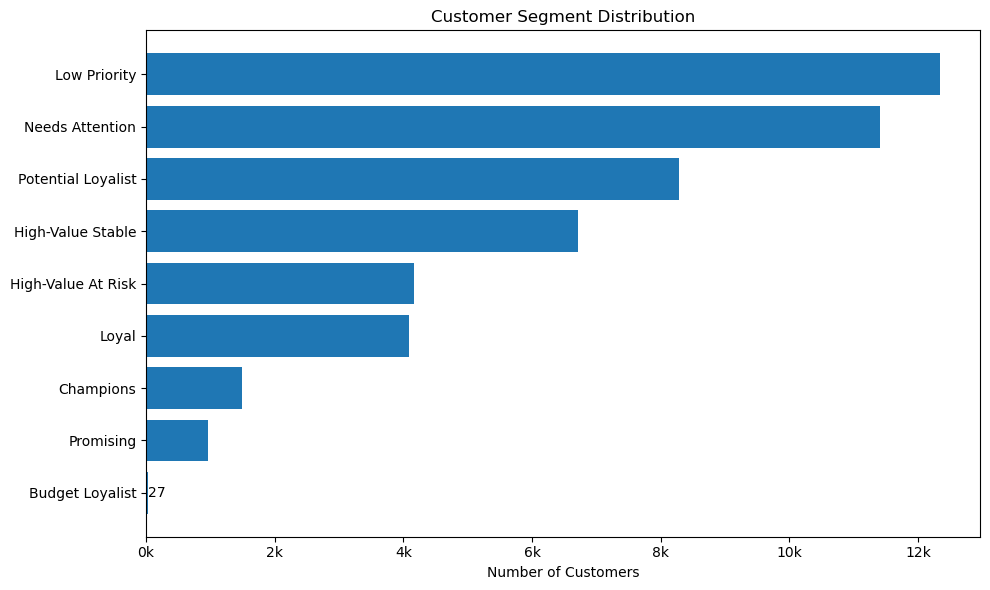

In [ ]:
import matplotlib.pyplot as plt

segment_size_sorted = segment_size.sort_values("customers", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(segment_size_sorted["combined_segment"], 
         segment_size_sorted["customers"])
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'{int(x/1000)}k'))

min_value = segment_size_sorted["customers"].min()

for i, value in enumerate(segment_size_sorted["customers"]):
    if value == min_value:
        plt.text(
            value + 10,
            i,
            str(value),
            va='center'
        )
        
plt.xlabel("Number of Customers")
plt.title("Customer Segment Distribution")
plt.tight_layout()


profit by segment:

In [7]:
segment_profit = (
    customer_segments
    .groupby("combined_segment")
    .agg(
        customers=("customerkey", "count"),
        avg_profit=("lifetime_profit", "mean"),
        total_profit=("lifetime_profit", "sum")
    )
    .reset_index()
)

segment_profit["avg_profit"] = segment_profit["avg_profit"].round(2)
segment_profit["total_profit"] = segment_profit["total_profit"].round(2)

segment_profit = segment_profit.sort_values("total_profit", ascending=False)
segment_profit

,combined_segment,customers,avg_profit,total_profit
3,High-Value Stable,6720,6021.42,40463924.28
2,High-Value At Risk,4159,6215.02,25848272.47
7,Potential Loyalist,8290,1972.36,16350843.80
1,Champions,1493,7620.46,11377352.92
6,Needs Attention,11408,808.53,9223725.72
5,Loyal,4082,2188.26,8932488.39
4,Low Priority,12345,177.32,2188976.13
8,Promising,963,1022.01,984191.40
0,Budget Loyalist,27,364.03,9828.91


graph rev by segment:

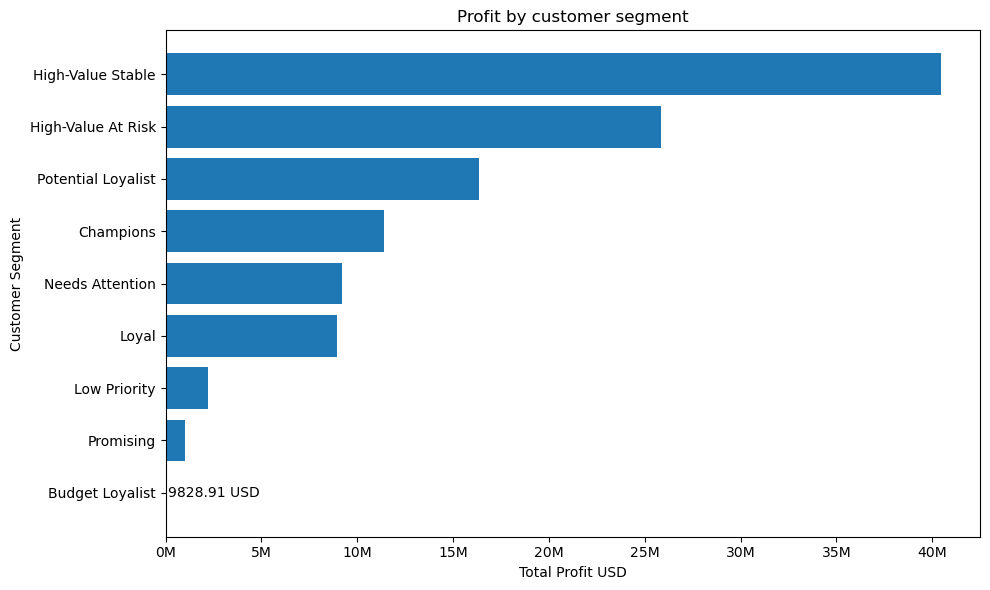

In [8]:
plt.figure(figsize=(10, 6))

plt.barh(
    segment_profit["combined_segment"],
    segment_profit["total_profit"]
)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x/1000000)}M'))
plt.gca().invert_yaxis()

for i, value in enumerate(segment_profit["total_profit"]):
    if value==segment_profit["total_profit"].min():
        plt.text(
            value + 100000,
            i,
            f'{str(value)} USD',
            va="center"
        )

plt.title("Profit by customer segment")
plt.xlabel("Total Profit USD")
plt.ylabel("Customer Segment")
plt.tight_layout()


rev by segment:

In [9]:
segment_revenue = (
    customer_segments
    .groupby("combined_segment")
    .agg(
        avg_revenue=("lifetime_revenue", "mean"),
        total_revenue=("lifetime_revenue", "sum")
    )
    .reset_index()
)

segment_revenue["avg_revenue"] = segment_revenue["avg_revenue"].round(2)
segment_revenue["total_revenue"] = segment_revenue["total_revenue"].round(2)

segment_revenue = segment_revenue.sort_values("total_revenue", ascending=False)
segment_revenue



,combined_segment,avg_revenue,total_revenue
3,High-Value Stable,10446.63,70201360.70
2,High-Value At Risk,10786.42,44860701.94
7,Potential Loyalist,3660.01,30341498.08
1,Champions,13511.75,20173049.26
6,Needs Attention,1547.67,17655779.90
5,Loyal,4111.62,16783642.85
4,Low Priority,350.15,4322554.38
8,Promising,1988.35,1914783.84
0,Budget Loyalist,732.43,19775.50
